In [28]:
# Feature Engineering

"""
This notebook creates flow-based features from packet data.

Goals:
- Group packets into flows
- Analyze communication patterns
- Generate ML-ready features
"""

'\nThis notebook creates flow-based features from packet data.\n\nGoals:\n- Group packets into flows\n- Analyze communication patterns\n- Generate ML-ready features\n'

In [ ]:
# Load data into data frames

df = pd.read_csv("../data/interim/packets_clean.csv")
df = df.sort_values("timestamp_raw")

In [ ]:
# Create flow sending devices ip -> receiving devices IP -> protocol -> port

df["flow"] = (
    df["src_ip"] + "_" +
    df["dst_ip"] + "_" +
    df["protocol"] + "_" +
    df["dst_port"].astype(str)
)

In [ ]:
# Flow analysis

flow_counts = df["flow"].value_counts()
flow_counts.head(10)

flow
192.168.0.22_192.168.0.53_UDP_58065      853
192.168.0.53_192.168.0.22_UDP_37152      746
192.168.0.53_192.168.0.22_UDP_43117      656
192.168.0.53_52.12.120.254_TCP_443       580
52.12.120.254_192.168.0.53_TCP_46692     403
192.168.0.53_216.105.169.18_UDP_10001    239
192.168.0.53_108.181.62.233_UDP_10001    238
192.168.0.53_108.181.23.175_UDP_10001    236
192.168.0.53_108.181.55.129_UDP_10001    234
54.148.40.77_192.168.0.203_TCP_60524     227
Name: count, dtype: int64

In [44]:
# Feature creation

flow_features = df.groupby("flow").agg({
    "packet_length": ["count", "mean", "std"],
    "time_diff": ["mean", "std"]
})

flow_features.columns = [
    "packet_count",
    "packet_size_mean",
    "packet_size_std",
    "time_mean",
    "time_std"
]

flow_features = flow_features.reset_index()

In [45]:
# Feature inspection

flow_features.head(10)

,flow,packet_count,packet_size_mean,packet_size_std,time_mean,time_std
0,100.21.159.71_192.168.0.53_TCP_50402,1,52.000000,NaN,NaN,NaN
1,100.21.159.71_192.168.0.53_TCP_50407,2,56.000000,5.656854,0.072036,NaN
2,100.21.159.71_192.168.0.53_TCP_50419,1,60.000000,NaN,NaN,NaN
3,100.21.159.71_192.168.0.53_TCP_50469,2,56.000000,5.656854,0.008000,NaN
4,108.181.23.175_192.168.0.53_UDP_58065,59,92.152542,44.472314,45.796654,68.771810
5,108.181.55.129_192.168.0.53_UDP_58065,45,89.066667,37.701218,60.368225,87.353024
6,108.181.62.233_192.168.0.53_UDP_58065,45,89.244444,37.657038,60.368225,76.692595
7,129.6.15.27_192.168.0.116_UDP_63672,1,76.000000,NaN,NaN,NaN
8,132.163.96.1_192.168.0.199_UDP_62957,1,76.000000,NaN,NaN,NaN
9,132.163.96.3_192.168.0.199_UDP_62958,1,76.000000,NaN,NaN,NaN


In [46]:
# Feature statistics

flow_features.describe()

,packet_count,packet_size_mean,packet_size_std,time_mean,time_std
count,308.000000,308.000000,197.000000,197.000000,159.000000
mean,24.827922,231.330875,215.163755,35.359954,63.783965
std,90.415434,213.262932,229.130740,116.170651,137.265615
min,1.000000,40.000000,0.000000,0.000000,0.000000
25%,1.000000,65.333333,5.656854,0.038686,0.064537
50%,3.000000,182.174679,138.486028,0.091246,0.152733
75%,10.000000,264.000000,406.843536,9.970049,45.705431
max,853.000000,1013.000000,736.141744,957.727420,790.390410


In [47]:
# Filtering flows

flow_features_filtered = flow_features[flow_features["packet_count"] > 10].copy()

print("Original flows:", len(flow_features))
print("Filtered flows:", len(flow_features_filtered))
flow_features_filtered.head()

Original flows: 308
Filtered flows: 68


,flow,packet_count,packet_size_mean,packet_size_std,time_mean,time_std
4,108.181.23.175_192.168.0.53_UDP_58065,59,92.152542,44.472314,45.796654,68.771810
5,108.181.55.129_192.168.0.53_UDP_58065,45,89.066667,37.701218,60.368225,87.353024
6,108.181.62.233_192.168.0.53_UDP_58065,45,89.244444,37.657038,60.368225,76.692595
11,18.214.19.97_192.168.0.199_TCP_52540,17,645.764706,633.050011,0.280000,0.856072
41,192.168.0.116_3.233.93.53_TCP_443,15,259.000000,419.906962,2.476857,7.975563


In [48]:
# Anonmaly detection on filtered flows 

from sklearn.ensemble import IsolationForest

model = IsolationForest(random_state=42)

feature_cols = ["packet_count", "packet_size_mean", "time_mean"]
X = flow_features_filtered[feature_cols].fillna(0)

flow_features_filtered["anomaly"] = model.fit_predict(X)

flow_features_filtered["anomaly"].value_counts()

anomaly
 1    55
-1    13
Name: count, dtype: int64

In [49]:
# Anomalous flow view

anomalies = flow_features_filtered[flow_features_filtered["anomaly"] == -1].copy()
anomalies.sort_values("packet_count", ascending=False).head(15)

,flow,packet_count,packet_size_mean,packet_size_std,time_mean,time_std,anomaly
95,192.168.0.22_192.168.0.53_UDP_58065,853,155.008206,171.152552,0.250731,4.796764,-1
110,192.168.0.53_192.168.0.22_UDP_37152,746,473.087131,313.701648,0.021487,0.036639,-1
111,192.168.0.53_192.168.0.22_UDP_43117,656,426.439024,314.841580,0.018599,0.033670,-1
133,192.168.0.53_52.12.120.254_TCP_443,580,58.441379,20.959992,2.253005,1.831922,-1
199,52.12.120.254_192.168.0.53_TCP_46692,403,72.235732,133.281308,3.244850,2.128056,-1
85,192.168.0.1_239.255.255.250_UDP_1900,143,520.699301,29.896072,12.256653,102.865622,-1
121,192.168.0.53_35.80.233.132_TCP_443,98,608.010204,625.850423,26.603932,121.264240,-1
97,192.168.0.232_192.168.0.255_UDP_57621,25,72.000000,0.000000,114.321309,272.276409,-1
11,18.214.19.97_192.168.0.199_TCP_52540,17,645.764706,633.050011,0.280000,0.856072,-1
130,192.168.0.53_44.235.109.71_TCP_8883,15,66.466667,16.008331,192.984128,253.597473,-1


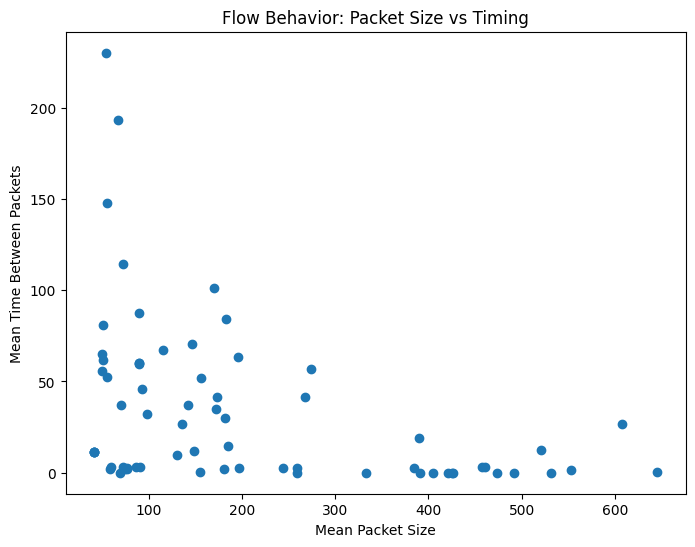

In [50]:
# scatter plot: packet size mean vs time mean

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    flow_features_filtered["packet_size_mean"],
    flow_features_filtered["time_mean"]
)
plt.xlabel("Mean Packet Size")
plt.ylabel("Mean Time Between Packets")
plt.title("Flow Behavior: Packet Size vs Timing")
plt.show()

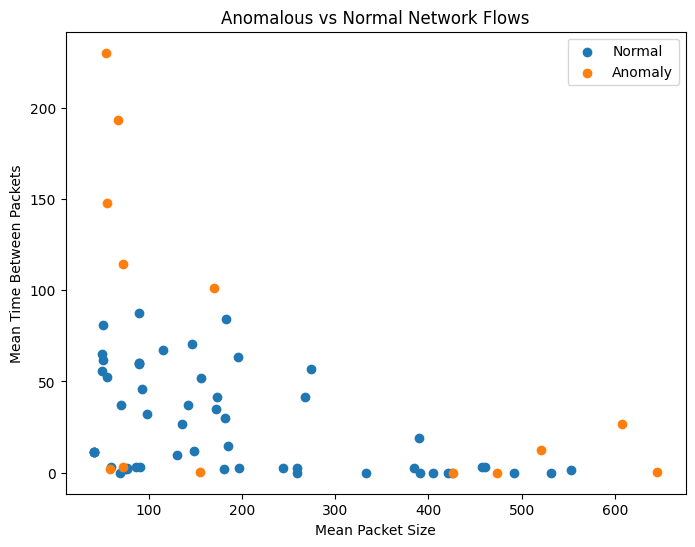

In [51]:
# Scatter plot with anomalies highlighted

normal = flow_features_filtered[flow_features_filtered["anomaly"] == 1]
anomaly = flow_features_filtered[flow_features_filtered["anomaly"] == -1]

plt.figure(figsize=(8, 6))
plt.scatter(
    normal["packet_size_mean"],
    normal["time_mean"],
    label="Normal"
)
plt.scatter(
    anomaly["packet_size_mean"],
    anomaly["time_mean"],
    label="Anomaly"
)

plt.xlabel("Mean Packet Size")
plt.ylabel("Mean Time Between Packets")
plt.title("Anomalous vs Normal Network Flows")
plt.legend()
plt.show()

In [ ]:
# Packet count distribution

plt.figure(figsize=(8, 6))
plt.hist(flow_features_filtered["packet_count"], bins=30)
plt.xlabel("Packet Count")
plt.ylabel("Number of Flows")
plt.title("Distribution of Packet Counts per Flow")
plt.show()